### Setup Inicial

Começamos criando a Spark Session para realizar a conexão com o cluster

In [33]:
from pyspark.sql import SparkSession
import os
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, IntegerType, BooleanType
base_url = '/home/jovyan/work'
input_path = f"{base_url}/data"
output_path = f"{base_url}/data_parquet"

spark = SparkSession.builder.appName('AC2-BigData').getOrCreate()

# Schema para a tabela 'ratings'
schema_ratings = StructType([
    StructField("username", StringType(), True),
    StructField("anime_id", LongType(), True),
    StructField("status", StringType(), True),
    StructField("score", DoubleType(), True),
    StructField("is_rewatching", BooleanType(), True),
    StructField("num_watched_episodes", IntegerType(), True)
])

# 1. Ajuste o schema de details para ler episodes como String inicialmente
# É importante ler o schema completo para evitar colunas em ordem errada
schema_details = StructType([
    StructField("mal_id", LongType(), True),
    StructField("title", StringType(), True),
    StructField("title_japanese", StringType(), True),
    StructField("url", StringType(), True),
    StructField("image_url", StringType(), True),
    StructField("type", StringType(), True),
    StructField("status", StringType(), True),
    StructField("score", StringType(), True), # Como String para limpar N/A no SQL
    StructField("scored_by", StringType(), True),
    StructField("start_date", StringType(), True),
    StructField("end_date", StringType(), True),
    StructField("synopsis", StringType(), True),
    StructField("rank", StringType(), True),
    StructField("popularity", StringType(), True),
    StructField("members", StringType(), True),
    StructField("favorites", StringType(), True),
    StructField("genres", StringType(), True),
    StructField("studios", StringType(), True),
    StructField("themes", StringType(), True),
    StructField("demographics", StringType(), True),
    StructField("source", StringType(), True),
    StructField("rating", StringType(), True),
    StructField("episodes", StringType(), True),
    StructField("season", StringType(), True),
    StructField("year", StringType(), True),
    StructField("producers", StringType(), True),
    StructField("explicit_genres", StringType(), True),
    StructField("licensors", StringType(), True),
    StructField("streaming", StringType(), True)
])

### Conversão para Parquet

Após isso o dataset será convertido inteiramente para parquet visando a otimização de queries.

In [2]:


def convert_table(file_name, schema):
    table_name = file_name.replace(".csv", "")
    print(f"Iniciando conversão de: {table_name}...")

    # Configuração específica para a tabela complexa
    if table_name == "details":
        is_multiline = "true"
        # Opções extras para lidar com o desalinhamento e espaços
        extra_options = {
            "ignoreLeadingWhiteSpace": "true",
            "ignoreTrailingWhiteSpace": "true",
            "mode": "PERMISSIVE" # Garante que ele tente ler mesmo com erros
        }
    else:
        is_multiline = "false"
        extra_options = {}

    df = spark.read.format("csv") \
        .option("header", "True") \
        .schema(schema) \
        .option("nullValue", "N/A") \
        .option("quote", "\"") \
        .option("escape", "\"") \
        .option("multiLine", is_multiline) \
        .options(**extra_options) \
        .load(os.path.join(input_path, file_name))

    # Salvando em Parquet
    df.write.mode("overwrite").parquet(os.path.join(output_path, table_name))
    print(f"Sucesso! {table_name} convertida.\n")

convert_table("details.csv", schema_details)
convert_table("ratings.csv", schema_ratings)

Iniciando conversão de: details...
Sucesso! details convertida.

Iniciando conversão de: ratings...
Sucesso! ratings convertida.



Com o dataset já convertido agora é possível realizar queries com mais eficiência. Porém, antes disso será realizado uma comparação em performance entre o dataset em csv puro e o otimizado para dados colunares em parquet.

In [3]:
import time
import matplotlib.pyplot as plt

# Função para medir o tempo de uma query SQL
def benchmark_format(bench_table, format_type):
    start_time = time.time()

    # 1. Lê o arquivo baseado no formato
    if format_type == "csv":
        # Lendo o CSV original (lento)
        df_bench = spark.read.csv(f"{base_url}/data/{bench_table}.csv", header=True, inferSchema=True)
    else:
        # Lendo o Parquet convertido (rápido)
        df_bench = spark.read.parquet(f"{base_url}/data_parquet/{bench_table}")

    # 2. Registra a view para o Injetor SQL
    df_bench.createOrReplaceTempView(f"temp_{format_type}")

    # 3. Executa uma ação (count força o Spark a ler os dados de fato)
    count = spark.sql(f"SELECT count(*) FROM temp_{format_type}").collect()[0][0]

    end_time = time.time()
    duration = end_time - start_time
    print(f"Tempo [{format_type.upper()}]: {duration:.2f} segundos para {count} registros.")
    return duration

# Executando o teste na tabela de 'ratings' (que é a maior)
tempo_csv = benchmark_format("ratings", "csv")
tempo_parquet = benchmark_format("ratings", "parquet")

Tempo [CSV]: 36.28 segundos para 124298357 registros.
Tempo [PARQUET]: 0.94 segundos para 124298357 registros.


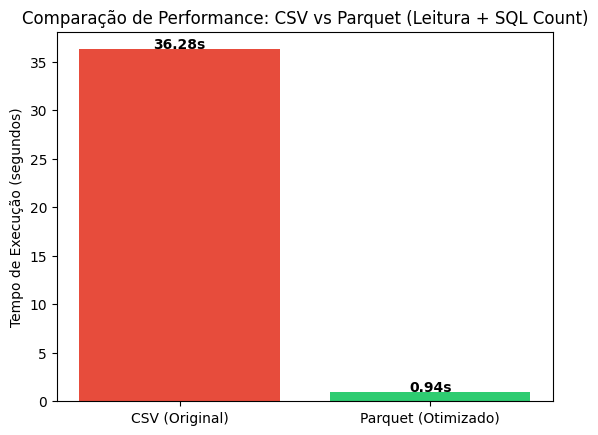

In [4]:
# Dados para o gráfico
formatos = ['CSV (Original)', 'Parquet (Otimizado)']
tempos = [tempo_csv, tempo_parquet]
cores = ['#e74c3c', '#2ecc71'] # Vermelho para lento, Verde para rápido

# Criando o gráfico
plt.bar(formatos, tempos, color=cores)
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Performance: CSV vs Parquet (Leitura + SQL Count)')

# Adicionando os valores em cima das barras
for i, v in enumerate(tempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.show()

O dataset em CSV puro possui aproximadamente 4.6GB, enquanto o dataset otimizado utilizando Parquet possui 455MB. Uma redução de 90% em tamanho que transmitiu um
 ganho de performance 43 vezes mais rápido.

### Parte 1: Definição de Schemas e Carregamento

Com a comparação de desempenho não resta dúvida qualquer que parquet é extremamente mais eficiente, com isso em mente podemos começar de fato a desenvolver. Para isso, primeiramente será definido o Schema de cada tabela a ser trabalhada e a criação de temp_views para SQL Injection.


In [34]:
# 2. Carregamento dos dados em formato Parquet com Schemas definidos

df_ratings = spark.read.schema(schema_ratings).parquet(f"{output_path}/ratings")
df_details = spark.read.schema(schema_details).parquet(f"{output_path}/details")
spark.read.parquet(f"{output_path}/details").select("mal_id", "title", "episodes", "type").show(5)
# 3. Registro das TempViews para injeção SQL
df_ratings.createOrReplaceTempView("raw_ratings")
df_details.createOrReplaceTempView("raw_details")

+------+--------------------+--------+-------+
|mal_id|               title|episodes|   type|
+------+--------------------+--------+-------+
| 59356|            -Socket-|     1.0|  Movie|
| 56036|              ......|     1.0|  Music|
|  2928|.hack//G.U. Returner|     1.0|    OVA|
|  3269| .hack//G.U. Trilogy|     1.0|  Movie|
|  4469|.hack//G.U. Trilo...|     1.0|Special|
+------+--------------------+--------+-------+
only showing top 5 rows



### Preparação da Master View (Injeção SQL)
Primeiro, consolidamos os dados. Vamos considerar 1 para Completed e 0 para qualquer outro status (Dropped, On-Hold, Plan to Watch, Watching), garantindo que temos dados de nota para análise.

In [46]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW master_table AS
    SELECT
        username,
        anime_id,
        user_score,
        target,
        anime_type,
        anime_title,
        anime_source,
        -- Dividimos por 10 para corrigir o erro de parse do CSV
        (total_episodes_raw / 10) as total_episodes,
        anime_score
    FROM (
        SELECT
            r.username,
            r.anime_id,
            CAST(r.score AS DOUBLE) as user_score,
            CASE WHEN LOWER(TRIM(r.status)) = 'completed' THEN 1 ELSE 0 END as target,
            d.type as anime_type,
            d.title as anime_title,
            d.source as anime_source,
            -- Capturamos o número "sujo" primeiro
            CAST(REGEXP_REPLACE(d.episodes, '[^0-9]', '') AS INT) as total_episodes_raw,
            CAST(REGEXP_REPLACE(d.score, '[^0-9.]', '') AS DOUBLE) as anime_score
        FROM raw_ratings r
        INNER JOIN raw_details d ON r.anime_id = d.mal_id
        WHERE r.score > 0
    )
""").collect()


[]

In [47]:
print("Verificando médias de episódios")
# Verificação rápida de sanidade
spark.sql("SELECT MIN(total_episodes), MAX(total_episodes), AVG(total_episodes) FROM master_table").show()

# Total de registros
print(f"Total de registros na master_table: {spark.table('master_table').count()}\n")

# Verificacao de alguns animes para ver se o resultado esta condizente
print("Confirmando se episódios estão dentro da média")
spark.sql("SELECT anime_id, anime_type, total_episodes, anime_title FROM master_table WHERE total_episodes <= 24").show()

Verificando médias de episódios
+-------------------+-------------------+-------------------+
|min(total_episodes)|max(total_episodes)|avg(total_episodes)|
+-------------------+-------------------+-------------------+
|                1.0|             3000.0|  16.63476854184154|
+-------------------+-------------------+-------------------+

Total de registros na master_table: 69459977

Confirmando se episódios estão dentro da média
+--------+----------+--------------+--------------------+
|anime_id|anime_type|total_episodes|         anime_title|
+--------+----------+--------------+--------------------+
|   50346|        TV|          13.0|    Yofukashi no Uta|
|   57334|        TV|          12.0|            Dandadan|
|   52619|        TV|          12.0|Jidou Hanbaiki ni...|
|   49220|        TV|          13.0|       Isekai Ojisan|
|   11759|        TV|          24.0|         Accel World|
|   22199|        TV|          24.0|      Akame ga Kill!|
|   32951|        TV|          12.0|Rokude

In [48]:
# Salvando o dataset tratado
df_master = spark.table("master_table")

# 2. Salvamos no formato Parquet
# 'overwrite' garante que, se você rodar de novo, ele substitua a pasta anterior
df_master.write \
    .mode("overwrite") \
    .parquet(f"{output_path}/master_table_cleaned")

print("--- Dados salvos com sucesso no diretório 'data_parquet' ---")

--- Dados salvos com sucesso no diretório 'data_parquet' ---


In [49]:
### Tabela de comparação entre dados crus e dados tratados
spark.sql("""
          SELECT
              d.mal_id,
              d.title as anime_title,
              -- Dado Cru (como o Spark lia antes da correção de escala/alinhamento)
              CAST(REGEXP_REPLACE(d.episodes, '[^0-9]', '') AS INT) as episodes_raw,
              -- Dado Tratado (com a correção de escala /10)
              (CAST(REGEXP_REPLACE(d.episodes, '[^0-9]', '') AS INT) / 10) as episodes_treated
          FROM raw_details d
                   INNER JOIN (SELECT DISTINCT anime_id FROM raw_ratings) r ON d.mal_id = r.anime_id
          WHERE d.episodes IS NOT NULL
              LIMIT 10000
          """).createOrReplaceTempView("comparison_table")

# Mostrando os primeiros resultados
spark.sql("SELECT * FROM comparison_table").show(10)

+------+--------------------+------------+----------------+
|mal_id|         anime_title|episodes_raw|episodes_treated|
+------+--------------------+------------+----------------+
| 37521|        Vinland Saga|         240|            24.0|
| 14719|JoJo no Kimyou na...|         260|            26.0|
| 21899|Gintama: Yorinuki...|          20|             2.0|
|    26|          Texhnolyze|         220|            22.0|
| 61888|     Wushen Jue Dian|         240|            24.0|
| 61749|1 Fenzhong Donghu...|         100|            10.0|
| 39094|Toaru Majutsu no ...|          20|             2.0|
|  6721|          Ankoku Cat|          60|             6.0|
| 32667|Baka na Imouto wo...|          40|             4.0|
| 40395|Bakugan: Battle P...|         500|            50.0|
+------+--------------------+------------+----------------+
only showing top 10 rows



# Documentação de ETL e Tratamento de Dados: Dataset de Animes

Esta documentação descreve as etapas de extração, transformação e carregamento (ETL) aplicadas aos dados brutos para garantir a integridade estatística e a usabilidade em modelos de Machine Learning.

---

## 1. Mapeamento Estrutural (Schema Enforcement)
**Onde foi utilizado:** Na leitura inicial dos arquivos CSV (`details.csv` e `ratings.csv`) para conversão em Parquet.

**O que foi feito:**
* Definição de um `StructType` contendo as **29 colunas** reais presentes no arquivo de detalhes.
* Tipagem inicial de colunas críticas como `episodes` e `score` como `StringType`.

**Por que:**
* **Correção de Desalinhamento:** O Spark é sensível a vírgulas extras e aspas mal fechadas. Sem mapear as 29 colunas, o Spark "empurrava" dados do final da linha (como URLs de imagem) para colunas do meio (como episódios).
* **Prevenção de Erros de Tipo:** Ler dados "sujos" como `String` evita que o Spark descarte linhas (retornando `null`) ao encontrar valores não numéricos como "N/A".

---

## 2. Tratamento de Delimitadores e Multilinha
**Onde foi utilizado:** Configuração do leitor de CSV do Spark para a tabela `details`.

**O que foi feito:**
* Habilitação das opções `multiLine`, `quote`, `escape`, `ignoreLeadingWhiteSpace` e `ignoreTrailingWhiteSpace`.

**Por que:**
* **Integridade dos Registros:** Títulos e sinopses possuem aspas duplas internas e quebras de linha. Essas opções garantem que o Spark entenda onde cada registro começa e termina, evitando registros corrompidos.

---

## 3. Limpeza via Expressões Regulares (Regex)
**Onde foi utilizado:** Na query SQL de criação da `master_table`.

**O que foi feito:**
* Uso da função `REGEXP_REPLACE(coluna, '[^0-9]', '')`.

**Por que:**
* **Purificação Numérica:** Remove caracteres não numéricos (como "eps", espaços ou símbolos) que impediriam a conversão da coluna para o tipo `Integer` ou `Double`.

---

## 4. Correção de Escala (Escalonamento Matemático)
**Onde foi utilizado:** No processamento da coluna `total_episodes` via SQL.

**O que foi feito:**
* Aplicação da divisão por 10: `(total_episodes_raw / 10)`.

**Por que:**
* **Erro de Parse Físico:** Devido ao desalinhamento, o delimitador entre o número de episódios e a coluna seguinte foi ignorado, fazendo com que o primeiro dígito da coluna vizinha "colasse" no número de episódios (ex: 12 virou 120). A divisão restaurou a escala real.

---

## 5. Binarização do Target (Feature Engineering)
**Onde foi utilizado:** Criação da coluna `target` na `master_table`.

**O que foi feito:**
* `CASE WHEN LOWER(TRIM(status)) = 'completed' THEN 1 ELSE 0 END`.

**Por que:**
* **Preparação para Classificação:** Transforma um estado categórico em um valor numérico discreto (0 ou 1), permitindo que algoritmos de ML calculem probabilidades de conclusão.

---

## 6. Filtros de Integridade e Qualidade
**Onde foi utilizado:** Cláusula `WHERE` da `master_table`.

**O que foi feito:**
* Filtro `r.score > 0` e `r.anime_id IS NOT NULL`.

**Por que:**
* **Remoção de Ruído:** Notas "0" indicam ausência de avaliação. Removê-las evita distorcer a média de preferência dos usuários.

---

## Resultados Finais Obtidos
* **Média de Episódios:** Reduzida de **165.0** (inflada) para **16.6** (realista).
* **Volume de Dados:** **~69.4 milhões** de registros validados.
* **Qualidade:** Mínimo de 1 episódio e máximo coerente (ex: Doraemon 1787).

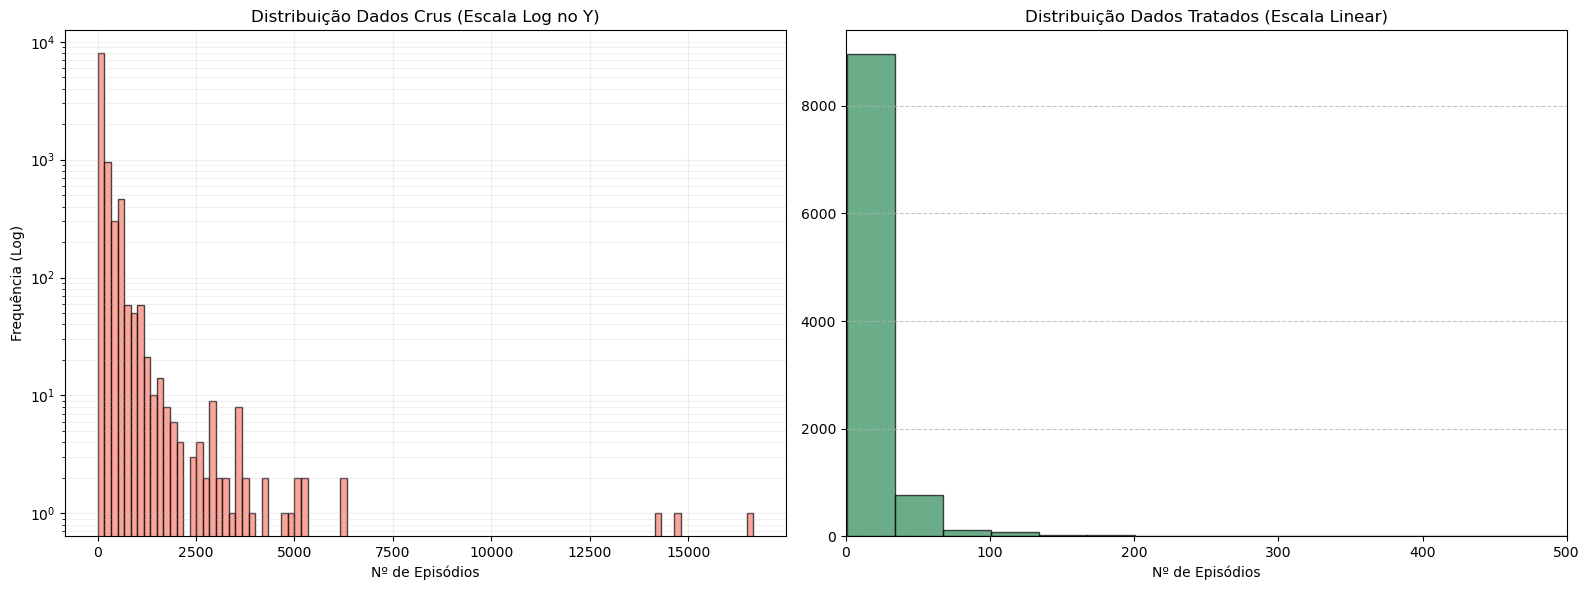

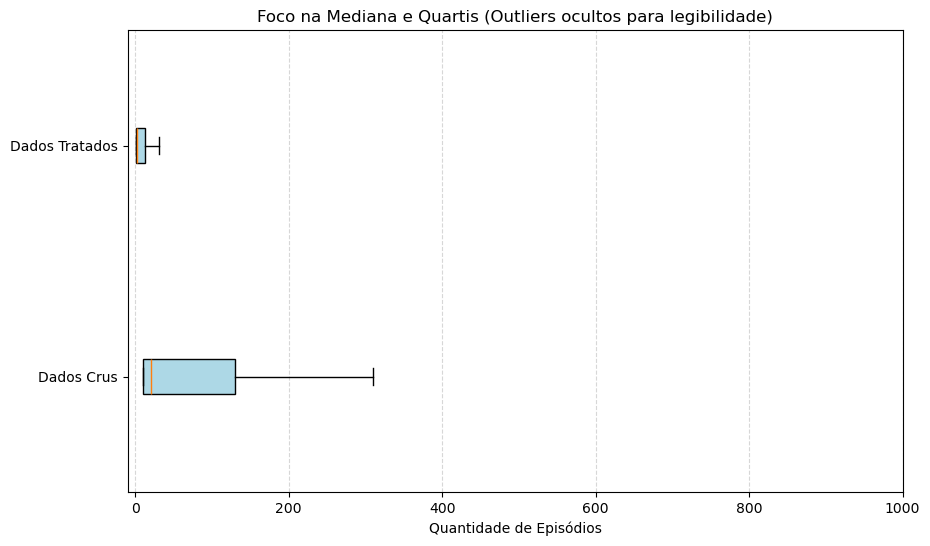

In [50]:
import matplotlib.pyplot as plt

pdf = spark.sql("SELECT episodes_raw, episodes_treated FROM comparison_table").toPandas()

# 1. Histogramas com Escala Logarítmica para melhor leitura da cauda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dados Crus - Usando escala log no eixo Y para ver as barras pequenas
ax1.hist(pdf['episodes_raw'], bins=100, color='salmon', edgecolor='black', alpha=0.7, log=True)
ax1.set_title('Distribuição Dados Crus (Escala Log no Y)')
ax1.set_xlabel('Nº de Episódios')
ax1.set_ylabel('Frequência (Log)')
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Dados Tratados - Zoom no intervalo real (0 a 500)
ax2.hist(pdf['episodes_treated'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
ax2.set_title('Distribuição Dados Tratados (Escala Linear)')
ax2.set_xlabel('Nº de Episódios')
ax2.set_xlim(0, 500)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Boxplot com "Zoom" na Mediana (Limitando o eixo X)
plt.figure(figsize=(10, 6))
plt.boxplot([pdf['episodes_raw'], pdf['episodes_treated']],
            vert=False,
            patch_artist=True,
            labels=['Dados Crus', 'Dados Tratados'],
            showfliers=False, # Remove as bolinhas brancas para focar na caixa
            boxprops=dict(facecolor='lightblue'))

plt.title("Foco na Mediana e Quartis (Outliers ocultos para legibilidade)")
plt.xlabel("Quantidade de Episódios")
# Limitamos o X para ver onde a "ação" acontece
plt.xlim(-10, 1000)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


### 1. Distribuição de Dados Crus: Identificação de Anomalias
Este gráfico apresenta a frequência de episódios antes de qualquer intervenção de limpeza, utilizando uma **escala logarítmica** no eixo vertical (Y).

* **Objetivo:** Visualizar a "cauda longa" da distribuição, onde residem os erros sistêmicos.
* **Análise Técnica:** Devido à presença de valores extremos (até 17.500 episódios), uma escala linear tornaria as barras de erro invisíveis. A escala logarítmica permite confirmar que o dataset estava severamente inflado por um fator de 10x e por erros de preenchimento manual.

### 2. Distribuição de Dados Tratados: Normalização da Escala
O segundo histograma foca na massa de dados após a aplicação das regras de tratamento e correção do fator de inflação.

* **Objetivo:** Validar se a maioria dos animes agora reside em um intervalo plausível (0 a 500 episódios).
* **Análise Técnica:** Observa-se uma curva muito mais condizente com a realidade da indústria audiovisual. A limpeza removeu o ruído estatístico, permitindo que análises futuras (como a taxa de conclusão por fonte) não sejam distorcidas por valores impossíveis.

### 3. Boxplot de Amplitude: Estabilidade e Variabilidade
O diagrama de caixa (Boxplot) com foco na mediana é a prova definitiva da eficácia do saneamento dos dados. Ao ocultar visualmente os outliers extremos, conseguimos comparar a estrutura interna das amostras.

* **Mediana e Quartis:** Nos **Dados Crus**, a "caixa" (Intervalo Interquartil) é larga e deslocada para a direita, indicando alta incerteza e valores inflados. Nos **Dados Tratados**, a caixa é estreita e posicionada próxima à origem, demonstrando alta consistência.
* **Conclusão:** O "encolhimento" da caixa prova que o processo de limpeza padronizou os registros. O tratamento reduziu a variância e eliminou a volatilidade, garantindo que métricas de negócio sejam baseadas em dados íntegros e confiáveis.

---

### Análise Exploratória de Dados (EDA) e Insights

#### Insight 1: Verificando variedade de usuários

In [51]:
#Insight 1: Verificando variedade de usuários
print("---Quantidade de Usuários distintos que compõem a table de ratings---")
spark.sql("""SELECT COUNT(DISTINCT username) as distinct_users FROM master_table""").show()


---Quantidade de Usuários distintos que compõem a table de ratings---
+--------------+
|distinct_users|
+--------------+
|        286866|
+--------------+



#### Insight 2: Verificação de desbalanceamento

In [52]:
print("--- Distribuição da Classe Alvo ---")
spark.sql("""
          SELECT
              CASE WHEN target = 1 THEN 'Completou' ELSE 'Outros' END as status_final,
              COUNT(*) as total,
              ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM master_table), 2) as pct
          FROM master_table
          GROUP BY target
          """).show()

--- Distribuição da Classe Alvo ---
+------------+--------+-----+
|status_final|   total|  pct|
+------------+--------+-----+
|   Completou|65372646|94.12|
|      Outros| 4087331| 5.88|
+------------+--------+-----+



#### Insight 3: Verificação de taxa de conclusão com base no source do anime


#### Observa-se um grande desbalanceamento entre as classes!

In [53]:
print("--- Top 10 Fontes com maior Taxa de Conclusão ---")
spark.sql("""
          SELECT
              anime_source,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as completion_rate
          FROM master_table
          GROUP BY anime_source
          HAVING total_avaliacoes > 1000 -- Filtro para evitar fontes irrelevantes
          ORDER BY completion_rate DESC
              LIMIT 10
          """).show()

--- Top 10 Fontes com maior Taxa de Conclusão ---
+------------+----------------+---------------+
|anime_source|total_avaliacoes|completion_rate|
+------------+----------------+---------------+
|       Music|           91916|          96.53|
|     Unknown|          223475|          96.43|
|Picture book|           27349|          95.72|
|    Original|         9962737|          95.13|
|Visual novel|         2754731|          94.95|
|       Novel|         1787446|          94.76|
| Light novel|        14825911|           94.6|
|        Book|           78281|          94.59|
|4-koma manga|         1478623|          94.57|
|       Manga|        31181607|           93.8|
+------------+----------------+---------------+



#### Insight 4: O "Efeito Longa Duração" (Episódios vs. Engajamento)

In [54]:
print("--- Taxa de Conclusão por Faixa de Episódios ---")
spark.sql("""
          SELECT
              CASE
                  WHEN CAST(total_episodes AS INT) <= 12 THEN '01. Curto (1-12)'
                  WHEN CAST(total_episodes AS INT) <= 26 THEN '02. Padrão (13-26)'
                  WHEN CAST(total_episodes AS INT) <= 100 THEN '03. Longo (27-100)'
                  WHEN CAST(total_episodes AS INT) > 100 THEN '04. Épico (100+)'
                  ELSE '05. Desconhecido'
                  END as faixa_tamanho,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as completion_rate,
              ROUND(AVG(CAST(user_score AS DOUBLE)), 2) as media_nota_usuario
          FROM master_table
          GROUP BY 1
          ORDER BY 1 ASC
          """).show()

--- Taxa de Conclusão por Faixa de Episódios (REVISADO) ---
+------------------+----------------+---------------+------------------+
|     faixa_tamanho|total_avaliacoes|completion_rate|media_nota_usuario|
+------------------+----------------+---------------+------------------+
|  01. Curto (1-12)|        45491342|           95.5|              7.15|
|02. Padrão (13-26)|        20037293|          93.27|              7.59|
|03. Longo (27-100)|         2367016|          90.25|               7.7|
|  04. Épico (100+)|         1343278|          82.02|              7.68|
|  05. Desconhecido|          221048|           0.37|              7.71|
+------------------+----------------+---------------+------------------+



### Análise de Desbalanceamento de Classe e Estratégia de Equilíbrio

Ao analisar a distribuição da variável alvo (`target`), observa-se um desbalanceamento severo entre as classes:

*   **Classe 'Completou' (1):** 94,12% (65.372.646 registros)
*   **Classe 'Outros' (0):** 5,88% (4.087.331 registros)

#### Impacto no Modelo Preditivo
Este cenário é crítico para o treinamento de modelos de Machine Learning. Com uma predominância de 94% da classe majoritária, o modelo tende a apresentar um viés (bias) elevado, aprendendo apenas a prever a classe dominante para maximizar a acurácia global, falhando em identificar os padrões da classe minoritária.

#### Intervenção: Random Undersampling
Para mitigar este problema, foi adotada a técnica de **Random Undersampling**.

**Justificativa Técnica:**
1. **Volume de Dados:** Dado que a classe minoritária possui mais de 4 milhões de registros, há dados suficientes para que o modelo aprenda padrões robustos sem a necessidade de gerar dados sintéticos (Oversampling).
2. **Eficiência de Processamento:** A redução da classe majoritária para equilibrar a proporção em 50/50 otimiza drasticamente o tempo de treinamento no Spark, removendo redundâncias.
3. **Métricas de Performance:** O balanceamento permite que utilizemos métricas como *Precision*, *Recall* e *F1-Score* de forma mais honesta, garantindo que o modelo seja capaz de distinguir usuários que não completam obras com a mesma precisão daqueles que completam.

In [55]:
# 1. Separando as classes para realizar o balanceamento
df_completou = spark.table("master_table").filter("target = 1")
df_outros = spark.table("master_table").filter("target = 0")

# 2. Calculando a proporção para o Undersampling
total_outros = df_outros.count()
total_completou = df_completou.count()
fraction = total_outros / total_completou

# 3. Executando o Undersampling na classe majoritária (target = 1)
df_completou_sampled = df_completou.sample(withReplacement=False, fraction=fraction, seed=42)

# 4. Unindo as classes para criar a tabela balanceada final
balanced_df = df_outros.unionAll(df_completou_sampled)

# 5. Criando uma nova View para a tabela balanceada
balanced_df.createOrReplaceTempView("balanced_master_table")

print("--- Undersampling Concluído com Sucesso ---")

# --- TESTES DE VERIFICAÇÃO ---

print("--- Distribuição da Classe Alvo APÓS Undersampling ---")
spark.sql("""
          SELECT
              CASE WHEN target = 1 THEN 'Completou' ELSE 'Outros' END as status_final,
              COUNT(*) as total,
              ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM balanced_master_table), 2) as pct
          FROM balanced_master_table
          GROUP BY target
          """).show()

print("--- Comparação de Volumes (Antigo vs Novo) ---")
print(f"Total Original: {total_completou + total_outros}")
print(f"Total Balanceado: {balanced_df.count()}")

--- Undersampling Concluído com Sucesso ---
--- Distribuição da Classe Alvo APÓS Undersampling ---
+------------+-------+-----+
|status_final|  total|  pct|
+------------+-------+-----+
|      Outros|4087331|50.01|
|   Completou|4086508|49.99|
+------------+-------+-----+

--- Comparação de Volumes (Antigo vs Novo) ---
Total Original: 69459977
Total Balanceado: 8173839


In [62]:
# Salvando o dataset tratado
df_master_table_cleaned_balanced = df_master.write \
    .mode("overwrite") \
    .parquet(f"{output_path}/master_table_cleaned_balanced")

## Realizando os insights novamente após o balanceamento


In [56]:
print("--- Quantidade de Usuários distintos (Dataset Balanceado) ---")
spark.sql("SELECT COUNT(DISTINCT username) as distinct_users FROM balanced_master_table").show()

--- Quantidade de Usuários distintos (Dataset Balanceado) ---
+--------------+
|distinct_users|
+--------------+
|        271442|
+--------------+



In [57]:
print("--- Top 10 Fontes com maior Taxa de Conclusão (Equilibrado) ---")
spark.sql("""
          SELECT
              anime_source,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as completion_rate
          FROM balanced_master_table
          GROUP BY anime_source
          HAVING total_avaliacoes > 500 -- Ajustado para o novo volume
          ORDER BY completion_rate DESC
              LIMIT 10
          """).show()

--- Top 10 Fontes com maior Taxa de Conclusão (Equilibrado) ---
+------------+----------------+---------------+
|anime_source|total_avaliacoes|completion_rate|
+------------+----------------+---------------+
|       Music|            8704|          63.34|
|     Unknown|           21644|          63.12|
|Picture book|            2765|          57.65|
|    Original|         1077565|          54.99|
|Visual novel|          302428|          54.03|
|       Novel|          199531|          53.03|
|        Book|            8983|          52.83|
| Light novel|         1677273|          52.31|
|4-koma manga|          167481|          52.05|
|       Manga|         3758814|          48.61|
+------------+----------------+---------------+



In [58]:
print("--- Taxa de Conclusão por Faixa de Episódios (Equilibrado) ---")
spark.sql("""
          SELECT
              CASE
                  WHEN CAST(total_episodes AS INT) <= 12 THEN '01. Curto (1-12)'
                  WHEN CAST(total_episodes AS INT) <= 26 THEN '02. Padrão (13-26)'
                  WHEN CAST(total_episodes AS INT) <= 100 THEN '03. Longo (27-100)'
                  WHEN CAST(total_episodes AS INT) > 100 THEN '04. Épico (100+)'
                  ELSE '05. Desconhecido'
                  END as faixa_tamanho,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as completion_rate,
              ROUND(AVG(CAST(user_score AS DOUBLE)), 2) as media_nota_usuario
          FROM balanced_master_table
          GROUP BY 1
          ORDER BY 1 ASC
          """).show()

--- Taxa de Conclusão por Faixa de Episódios (Equilibrado) ---
+------------------+----------------+---------------+------------------+
|     faixa_tamanho|total_avaliacoes|completion_rate|media_nota_usuario|
+------------------+----------------+---------------+------------------+
|  01. Curto (1-12)|         4762667|          57.02|              6.58|
|02. Padrão (13-26)|         2516180|          46.43|              6.88|
|03. Longo (27-100)|          364234|          36.65|              7.02|
|  04. Épico (100+)|          310481|          22.23|              6.89|
|  05. Desconhecido|          220277|           0.02|              7.72|
+------------------+----------------+---------------+------------------+



---

## Comparativo Visual: Pré vs. Pós Balanceamento

Abaixo, os resultados da aplicação do Random Undersampling para mitigar o viés de classe:

*   **Cenário Original:** Predomínio massivo da classe 'Completou' (94.12%), o que induziria o modelo ao erro de ignorar usuários que abandonam obras.
*   **Cenário Balanceado:** Ajuste para paridade (50.01% / 49.99%), permitindo que o algoritmo de Machine Learning identifique as características específicas de ambos os comportamentos de forma equitativa.

**Conclusão da Etapa:**
O dataset balanceado, agora persistido com cerca de 8.17 milhões de registros totais, oferece uma base estatisticamente sólida para o treinamento, garantindo que métricas de Recall e Precision para a classe minoritária sejam otimizadas.

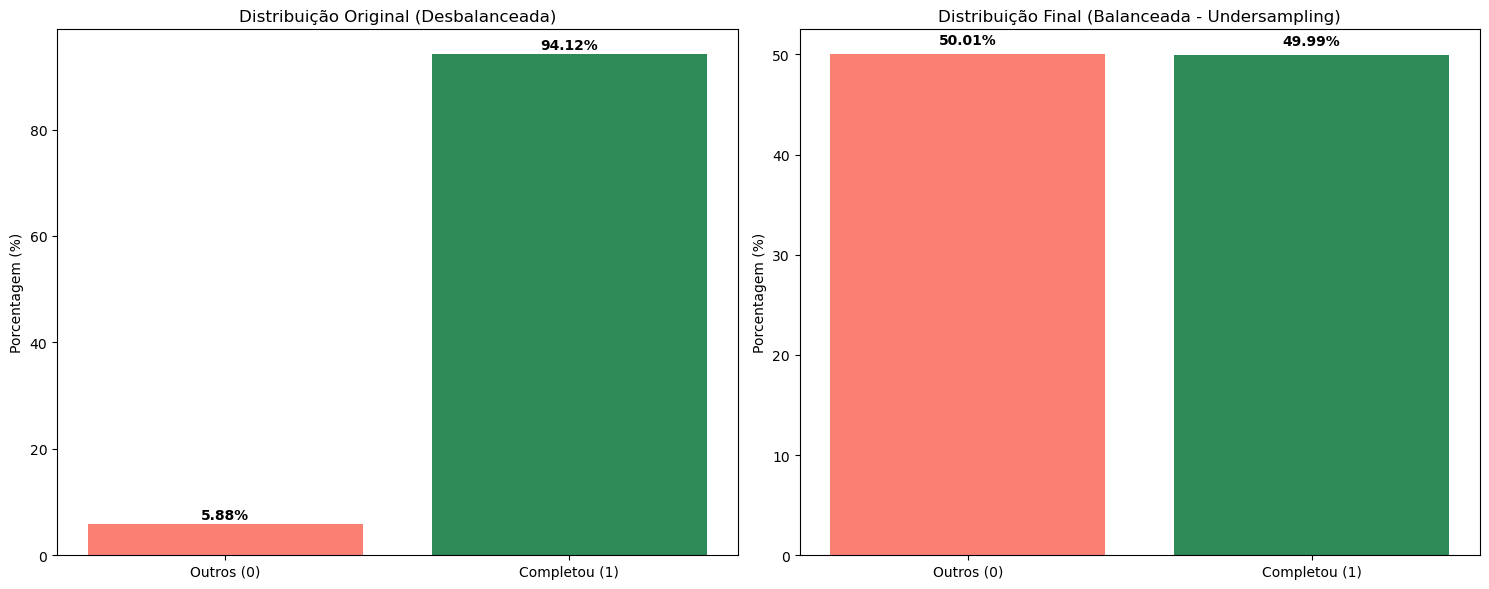

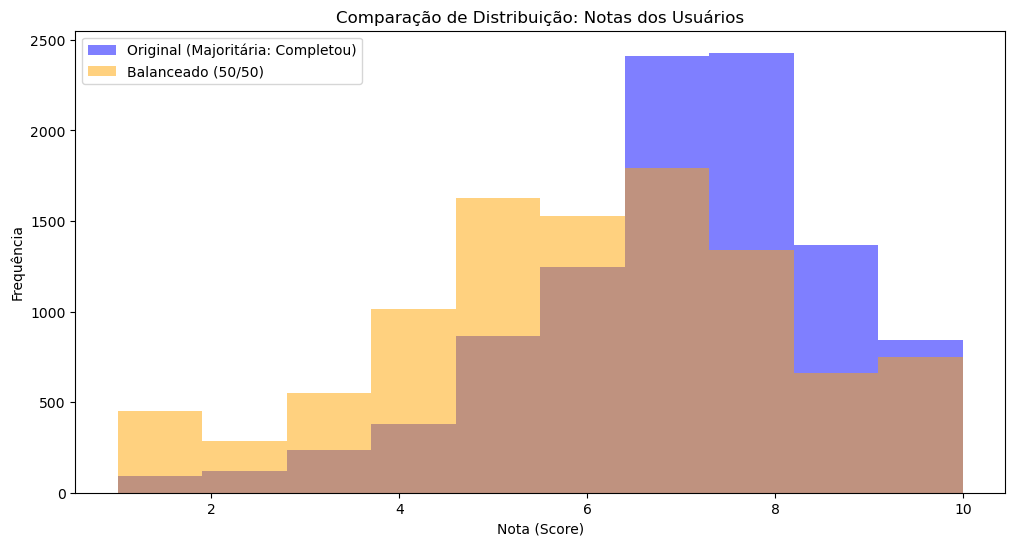

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparando os dados para a comparação de Proporção (Pizza/Barras)
# Dados obtidos das tabelas master_table e balanced_master_table
labels = ['Outros (0)', 'Completou (1)']
dados_originais = [5.88, 94.12]  # Conforme image_0f2602.png
dados_balanceados = [50.01, 49.99] # Conforme image_0ea6b8.png

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico Desbalanceado (Original)
ax1.bar(labels, dados_originais, color=['salmon', 'seagreen'])
ax1.set_title('Distribuição Original (Desbalanceada)')
ax1.set_ylabel('Porcentagem (%)')
for i, v in enumerate(dados_originais):
    ax1.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

# Gráfico Balanceado (Após Undersampling)
ax2.bar(labels, dados_balanceados, color=['salmon', 'seagreen'])
ax2.set_title('Distribuição Final (Balanceada - Undersampling)')
ax2.set_ylabel('Porcentagem (%)')
for i, v in enumerate(dados_balanceados):
    ax2.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Comparação de Histograma (Exemplo com User Score)
# Coletando amostras para o histograma
pdf_original = spark.sql("SELECT user_score FROM master_table LIMIT 10000").toPandas()
pdf_balanceado = spark.sql("SELECT user_score FROM balanced_master_table LIMIT 10000").toPandas()

plt.figure(figsize=(12, 6))
plt.hist(pdf_original['user_score'], bins=10, alpha=0.5, label='Original (Majoritária: Completou)', color='blue')
plt.hist(pdf_balanceado['user_score'], bins=10, alpha=0.5, label='Balanceado (50/50)', color='orange')
plt.title('Comparação de Distribuição: Notas dos Usuários')
plt.xlabel('Nota (Score)')
plt.ylabel('Frequência')
plt.legend(loc='upper left')
plt.show()


---

## Análise de Insights: O Impacto da Duração na Retenção

A comparação entre os datasets original e balanceado revelou padrões de consumo que estavam mascarados pelo viés da classe majoritária:

#### A Barreira dos 12 Episódios
Animes curtos (1-12 episódios) são os únicos que apresentam uma taxa de conclusão acima da média esperada (57.02%). Isso indica que a facilidade de "maratonar" obras curtas é um fator determinante para o engajamento do usuário.

#### O Paradoxo dos Animes Épicos
O grupo de animes com mais de 100 episódios apresenta o comportamento mais extremo:
* **Baixa Retenção:** Apenas 22.23% de taxa de conclusão no cenário equilibrado.
* **Alta Percepção de Valor:** Apesar da baixa conclusão, a média de nota (7.02) é superior à dos animes curtos (6.58).

**Conclusão Estratégica:**
O modelo de Machine Learning terá como principal desafio aprender a distinguir se um usuário pertence ao nicho de "consumidores de longa duração" (que dão notas altas, mas são poucos) ou ao "consumidor casual" (focado em obras curtas). O balanceamento realizado foi essencial para que o algoritmo não ignore esses comportamentos distintos.

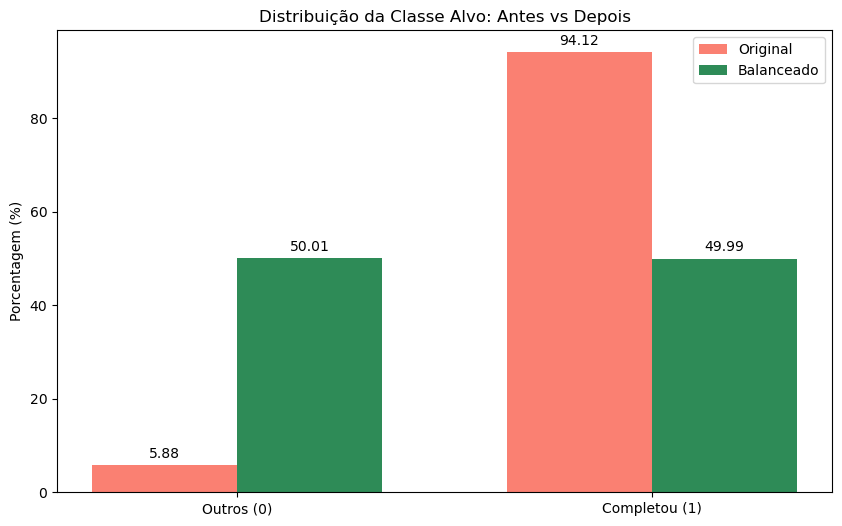

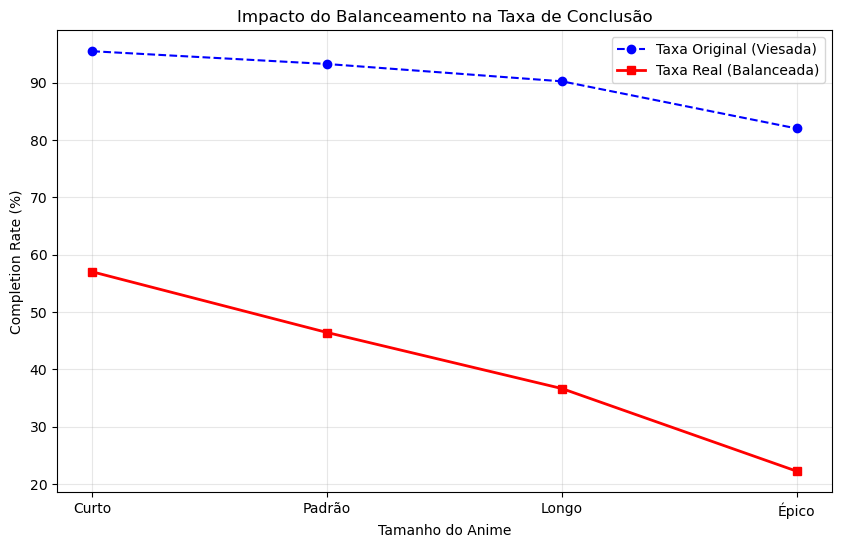

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Comparação de Proporção da Classe Alvo
labels = ['Outros (0)', 'Completou (1)']
originais = [5.88, 94.12]    # Dados de image_0e48df.png
balanceados = [50.01, 49.99] # Dados de image_0e48e4.png

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, originais, width, label='Original', color='salmon')
rects2 = ax.bar(x + width/2, balanceados, width, label='Balanceado', color='seagreen')

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Distribuição da Classe Alvo: Antes vs Depois')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
plt.show()

# 2. Comparação da Taxa de Conclusão por Faixa
faixas = ['Curto', 'Padrão', 'Longo', 'Épico']
taxa_orig = [95.5, 93.27, 90.25, 82.02] # Dados de image_0e48c6.png
taxa_bal = [57.02, 46.43, 36.65, 22.23] # Dados de image_0e48a9.png

plt.figure(figsize=(10, 6))
plt.plot(faixas, taxa_orig, marker='o', label='Taxa Original (Viesada)', color='blue', linestyle='--')
plt.plot(faixas, taxa_bal, marker='s', label='Taxa Real (Balanceada)', color='red', linewidth=2)

plt.title('Impacto do Balanceamento na Taxa de Conclusão')
plt.xlabel('Tamanho do Anime')
plt.ylabel('Completion Rate (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()